# Driver sequence identification

Macro recall@k as bar plots. Layout: 3 horizontal panels by k (100, 1000, 10000). Each panel has 3 vertically-stacked subpanels for diseases (HIV, Covid19, Influenza). X-axis within each subpanel is the method. A horizontal dashed line shows the random-chance baseline (mean k/N) per (disease, k).

In [66]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## Config

In [67]:
METHODS = [
    "Emerson 2017",
    "V/J-gkmer (LogReg)",
    "V/J-gkmer (XGBoost)",
    "ABMIL",
    "DeepRC",
    "GIANA",
]

METHOD_SHORT = {
    "Emerson 2017":        "Emerson",
    "V/J-gkmer (LogReg)":  "V/J-gkmer\n(LR)",
    "V/J-gkmer (XGBoost)": "V/J-gkmer\n(XGB)",
    "ABMIL":               "ABMIL",
    "DeepRC":              "DeepRC",
    "GIANA":               "GIANA",
}

DISEASES = ["HIV", "Covid19", "Influenza"]

K_VALUES = [100, 1000, 10000]

METHOD_COLORS = {
    "Emerson 2017":        "#332288",
    "Ostmeyer 2019":       "#DDCC77",
    "V/J-gkmer (LogReg)":  "#CC6677",
    "V/J-gkmer (XGBoost)": "#AA4499",
    "ABMIL":               "#CB9947",
    "GIANA":               "#88CCEE",
    "DeepRC":              "#117733",
    "DeepTCR":             "#44AA99",
    "Mal-ID":              "#882255",
}

NA = np.nan

## Results table

Macro recall@k per (disease, method, k). k order: 100, 1000, 10000.

In [68]:
RESULTS = {
    "HIV": {
        "Emerson 2017":        [0.0168, 0.0928, 0.4333],
        "V/J-gkmer (LogReg)":  [0.0005, 0.0320, 0.4218],
        "V/J-gkmer (XGBoost)": [0.0005, 0.0203, 0.2910],
        "ABMIL":               [0.0037, 0.0326, 0.3943],
        "DeepRC":              [0.0000, 0.0155, 0.1797],
        "GIANA":               [0.0069, 0.0725, 0.2311],
    },
    "Covid19": {
        "Emerson 2017":        [0.0478, 0.2914, 0.7883],
        "V/J-gkmer (LogReg)":  [0.0120, 0.1134, 0.6878],
        "V/J-gkmer (XGBoost)": [0.0060, 0.0811, 0.6230],
        "ABMIL":               [0.0065, 0.0734, 0.7517],
        "DeepRC":              [0.0047, 0.0623, 0.7314],
        "GIANA":               [0.0101, 0.2096, 0.5543],
    },
    "Influenza": {
        "Emerson 2017":        [0.0104, 0.1379, 0.4859],
        "V/J-gkmer (LogReg)":  [0.0041, 0.0277, 0.3911],
        "V/J-gkmer (XGBoost)": [0.0038, 0.0356, 0.3727],
        "ABMIL":               [0.0021, 0.0330, 0.4237],
        "DeepRC":              [0.0002, 0.0106, 0.2148],
        "GIANA":               [0.0035, 0.0908, 0.2815],
    },
}

# Random-chance baseline: mean k/N per (disease, k). Fill in actual values.
# k order: 100, 1000, 10000.
RANDOM_BASELINE = {
    "HIV":       [0.0033, 0.0329, 0.3201],
    "Covid19":   [0.0086, 0.0862, 0.7217],
    "Influenza": [0.0032, 0.0321, 0.3212],
}

## Plot helpers

In [69]:
def plot_subpanel(ax, disease, k_idx):
    x_pos = np.arange(len(METHODS)) * 0.7
    heights = []
    colors = []
    for method in METHODS:
        val = RESULTS[disease][method][k_idx]
        heights.append(val if not np.isnan(val) else 0.0)
        colors.append(METHOD_COLORS[method])
    ax.bar(x_pos, heights, width=0.56, color=colors, edgecolor="black", linewidth=0.6)

    baseline = RANDOM_BASELINE[disease][k_idx]
    if not np.isnan(baseline):
        ax.axhline(
            baseline, color="gray", linestyle="--", linewidth=1.4,
            label="Random",
        )

    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlim(-0.42, (len(METHODS) - 1) * 0.7 + 0.42)
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)


def make_figure(out_path=None):
    fig, axes = plt.subplots(
        len(DISEASES), len(K_VALUES),
        figsize=(9.5, 6.0),
    )
    fig.subplots_adjust(
        left=0.14, right=0.99, top=0.93, bottom=0.18,
        wspace=0.32, hspace=0.28,
    )

    for col, k in enumerate(K_VALUES):
        axes[0, col].set_title(f"k = {k:,}", fontsize=14, fontweight="bold")
        for row, disease in enumerate(DISEASES):
            plot_subpanel(axes[row, col], disease, col)

    # Disease names per row (leftmost subplot's ylabel).
    for row, disease in enumerate(DISEASES):
        ax = axes[row, 0]
        ax.set_ylabel(disease, fontsize=13, fontweight="bold")
        ax.yaxis.set_label_coords(-0.22, 0.5)

    # Single shared y-axis title at the very left of the figure.
    fig.text(
        0.015, (0.93 + 0.18) / 2, "Recall@k (macro)",
        rotation=90, ha="left", va="center",
        fontsize=13, fontweight="bold",
    )

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=METHOD_COLORS[m], ec="black", lw=0.6)
        for m in METHODS
    ]
    labels = list(METHODS)
    handles.append(plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1.4))
    labels.append("Random (k/N)")
    fig.legend(
        handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.0),
        ncol=4, frameon=False, fontsize=11,
    )

    if out_path:
        fig.savefig(out_path, bbox_inches="tight")
    return fig

## Render

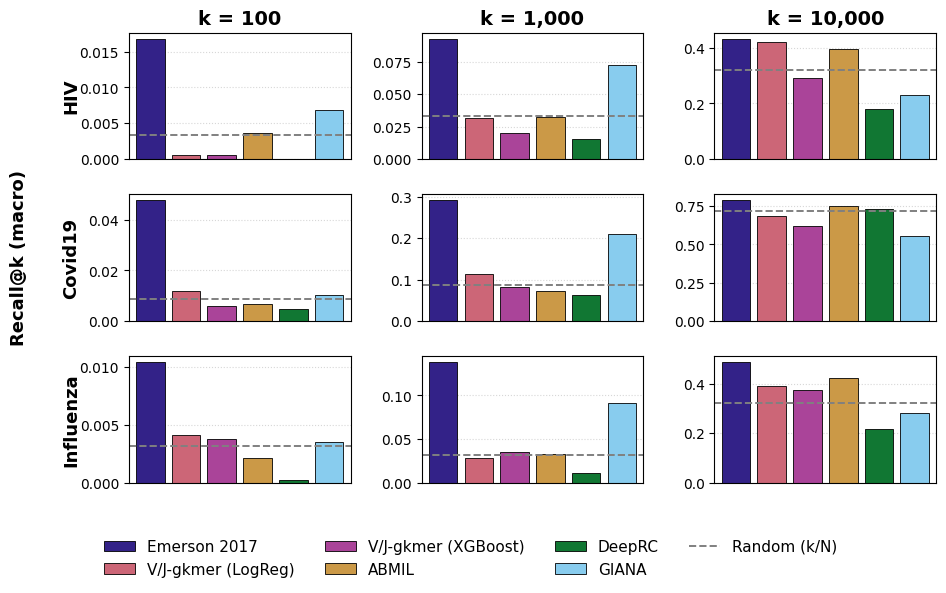

In [70]:
fig = make_figure(out_path="driver_seq_id.pdf")
plt.show()

## Connected scatter plot version

Alternative layout: one panel per disease (3 panels side-by-side). Within each panel, x-axis is k (log scale) and there is one connected line per method. Random-chance baseline shown as dashed gray line.

In [ ]:
def plot_disease_panel(ax, disease):
    for method in METHODS:
        ys = RESULTS[disease][method]
        ax.plot(
            K_VALUES, ys,
            marker="o", linewidth=1.8, markersize=6,
            color=METHOD_COLORS[method], label=method,
        )

    baseline = RANDOM_BASELINE[disease]
    if not all(np.isnan(baseline)):
        ax.plot(
            K_VALUES, baseline,
            color="gray", linestyle="--", linewidth=1.4,
            label="Random (k/N)",
        )

    ax.set_xscale("log")
    ax.set_xticks(K_VALUES)
    ax.set_xticklabels([f"{k:,}" for k in K_VALUES])
    ax.set_xlabel("k", fontsize=12)
    ax.set_title(disease, fontsize=13, fontweight="bold")
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)

    method_vals = [v for m in METHODS for v in RESULTS[disease][m]
                   if not np.isnan(v)]
    baseline_vals = [v for v in RANDOM_BASELINE[disease] if not np.isnan(v)]
    panel_max = max(method_vals + baseline_vals)
    ymax = panel_max * 1.08
    ymin = -0.04 * ymax
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.linspace(0, ymax, 6))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))


def make_line_figure(out_path=None):
    fig, axes = plt.subplots(
        1, len(DISEASES),
        figsize=(13, 4.2),
        constrained_layout=True,
        sharey=False,
    )

    for ax, disease in zip(axes, DISEASES):
        plot_disease_panel(ax, disease)

    axes[0].set_ylabel("Recall@k (macro)", fontsize=12, fontweight="bold")

    handles = [
        plt.Line2D([0], [0], color=METHOD_COLORS[m], marker="o", linewidth=1.8, markersize=6)
        for m in METHODS
    ]
    labels = list(METHODS)
    handles.append(plt.Line2D([0], [0], color="gray", linestyle="--", linewidth=1.4))
    labels.append("Random (k/N)")
    fig.legend(
        handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.08),
        ncol=len(handles), frameon=False, fontsize=11,
    )

    if out_path:
        fig.savefig(out_path, bbox_inches="tight")
    return fig


fig = make_line_figure(out_path="driver_seq_id_lines.pdf")
plt.show()